# 🔫 Updated Gunshot Trimmer — Configurable Duration

> Extracts verified gunshot clips from raw audio with strict quality gates.
> **Key upgrade**: Clip duration is fully configurable (no longer locked to 250ms).

### Paper References
- **Magee et al. (2019)** — Uses 2.0s windows on Raspberry Pi
- **Saha et al. (2025)** — 0.5-1.0s windows for forest environments
- **Edge Impulse Arduino Projects** — 1.0s windows for Nano 33 BLE

In [1]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
%pip install -q librosa soundfile pandas numpy tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ============================================================
# CELL 2: Imports
# ============================================================
import librosa
import librosa.display
import numpy as np
import pandas as pd
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import json
import shutil
import random
import re
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print(' All imports loaded successfully.')

✅ All imports loaded successfully.


c:\ProgramData\anaconda3\envs\guns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# CELL 3: CONFIGURATION — CHANGE THESE SETTINGS
# ============================================================

# ==========================================================
# 🎯 CLIP DURATION — THE KEY SETTING
# ==========================================================
# Options: 250, 500, 750, 1000, 1500, 2000
# Academic standard: 500-2000ms for classification windows
# Recommended: 1000ms (best balance of accuracy & memory)
TARGET_MS = 750
# ==========================================================

# --- Path Auto-Detection ---
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'Data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# !! TO HARDCODE: Uncomment the line below !!
# PROJECT_ROOT = Path(r'd:\Desktop\GShot\Data-Cleaner')

DATA_DIR = PROJECT_ROOT / 'Data'

# --- Dynamic output folder name ---
OUTPUT_DIR = DATA_DIR / f'TRIMMED_GUNSHOTS_{TARGET_MS}MS'

# --- Audio Parameters (auto-calculated from TARGET_MS) ---
SAMPLE_RATE = 22050
TARGET_SAMPLES = int(SAMPLE_RATE * TARGET_MS / 1000)

# Pre-event padding scales with clip duration
# 250ms → 50ms pre-event, 1000ms → 200ms pre-event
PRE_EVENT_MS = max(50, int(TARGET_MS * 0.2))
PRE_EVENT_SAMPLES = int(SAMPLE_RATE * PRE_EVENT_MS / 1000)

MAX_CLIPS_PER_FILE = 8

# --- Source Directories ---
CLASS1_DIRS = [DATA_DIR / 'gun', DATA_DIR / 'edge-collected-gunshot-audio']

# --- Quality Gate Thresholds ---
PEAK_MIN = 0.01
RMS_MIN = 0.002
CREST_MIN = 3.0
PROMINENCE_MIN = 4.0
P95_MIN = 0.002
CENTROID_MIN = 1500.0

# --- Clean previous output? ---
OVERWRITE = True

# --- Print config ---
print(f'Project Root    : {PROJECT_ROOT}')
print(f'Data Directory  : {DATA_DIR}')
print(f'Output          : {OUTPUT_DIR}')
print(f'Clip Duration   : {TARGET_MS}ms = {TARGET_SAMPLES} samples @ {SAMPLE_RATE}Hz')
print(f'Pre-Event       : {PRE_EVENT_MS}ms = {PRE_EVENT_SAMPLES} samples')
print(f'Max Clips/File  : {MAX_CLIPS_PER_FILE}')
print(f'Overwrite       : {OVERWRITE}')
assert DATA_DIR.exists(), f'❌ Data directory not found: {DATA_DIR}'

Project Root    : C:\order\Desktop\Gun\Data-Cleaner
Data Directory  : C:\order\Desktop\Gun\Data-Cleaner\Data
Output          : C:\order\Desktop\Gun\Data-Cleaner\Data\TRIMMED_GUNSHOTS_750MS
Clip Duration   : 750ms = 16537 samples @ 22050Hz
Pre-Event       : 150ms = 3307 samples
Max Clips/File  : 8
Overwrite       : True


In [ ]:
# ============================================================
# CELL 4: Helper Functions
# ============================================================
JUNK_TOKENS = ('__MACOSX',)
SAFE_NAME_RE = re.compile(r'[^A-Za-z0-9._-]+')


def is_junk(path):
    as_str = str(path)
    return any(t in as_str for t in JUNK_TOKENS) or path.name.startswith('._')


def sanitize_name(raw, max_len=120):
    cleaned = SAFE_NAME_RE.sub('_', raw.strip()).strip('._')
    return (cleaned or 'clip')[:max_len]


def collect_wavs(dirs):
    files = []
    for d in dirs:
        if d.exists():
            files.extend([f for f in d.rglob('*.wav') if not is_junk(f)])
    return sorted(files)


def load_audio(path):
    y, _ = librosa.load(str(path), sr=SAMPLE_RATE, mono=True)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    return y.astype(np.float32)


def force_exact_length(clip):
    if len(clip) == TARGET_SAMPLES:
        return clip
    if len(clip) > TARGET_SAMPLES:
        return clip[:TARGET_SAMPLES]
    return np.pad(clip, (0, TARGET_SAMPLES - len(clip)), mode='constant')


def normalize_clip(clip):
    clip = clip - np.mean(clip)
    peak = float(np.max(np.abs(clip))) if len(clip) else 0.0
    if peak > 0.999:
        clip = clip / peak * 0.999
    return clip.astype(np.float32)


def write_clip(path, clip):
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), clip, SAMPLE_RATE, subtype='PCM_16')
    if not path.exists() or path.stat().st_size <= 44:
        raise IOError(f'Empty/invalid file written: {path}')


print(' Helper functions defined.')

✅ Helper functions defined.


In [ ]:
# ============================================================
# CELL 5: Multi-Onset Gunshot Detection (Enhanced Sniper Method)
# ============================================================

def find_gunshot_onsets(y):
    """
    Find all candidate gunshot onset positions in the audio.
    Uses three detection methods simultaneously, then ranks by strength.
    Returns: list of center sample positions, ordered by strength.
    """
    if y is None or len(y) < 100:
        return []
    
    abs_y = np.abs(y)
    
    # --- Method 1: Onset detection (spectral flux) ---
    hop = 128
    onset_env = librosa.onset.onset_strength(y=y, sr=SAMPLE_RATE, hop_length=hop)
    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_env, sr=SAMPLE_RATE, hop_length=hop,
        backtrack=False, pre_max=3, post_max=3, pre_avg=3, post_avg=3,
        delta=0.1, wait=2
    )
    onset_samples = [int(f * hop) for f in onset_frames]
    
    # --- Method 2: Raw peak ---
    peak_raw = int(np.argmax(abs_y))
    
    # --- Method 3: Smoothed envelope peak ---
    smooth_kernel = max(3, int(0.005 * SAMPLE_RATE))
    kernel = np.ones(smooth_kernel, dtype=np.float32) / smooth_kernel
    envelope = np.convolve(abs_y, kernel, mode='same')
    peak_env = int(np.argmax(envelope))
    
    # --- Combine and score all candidates ---
    candidates = [peak_raw, peak_env] + onset_samples
    diff = np.abs(np.diff(y, prepend=0.0))
    
    scores = {}
    for c in candidates:
        if 0 <= c < len(y):
            scores[c] = float(abs_y[c]) + float(diff[c])
    
    sorted_candidates = [c for c, _ in sorted(scores.items(), key=lambda kv: kv[1], reverse=True)]
    
    # --- Filter overlapping candidates (minimum gap based on clip size) ---
    min_gap = max(TARGET_SAMPLES // 2, int(SAMPLE_RATE * 0.03))
    filtered = []
    for c in sorted_candidates:
        if all(abs(c - kept) >= min_gap for kept in filtered):
            filtered.append(c)
        if len(filtered) >= MAX_CLIPS_PER_FILE:
            break
    
    return filtered


def extract_clip_at_onset(y, center):
    """
    Extract a clip centered around the onset.
    Places the onset at PRE_EVENT_SAMPLES from start.
    """
    start = int(center) - PRE_EVENT_SAMPLES
    end = start + TARGET_SAMPLES
    
    pad_left = max(0, -start)
    pad_right = max(0, end - len(y))
    src_start = max(0, start)
    src_end = min(len(y), end)
    
    clip = y[src_start:src_end]
    if pad_left > 0 or pad_right > 0:
        clip = np.pad(clip, (pad_left, pad_right), mode='constant')
    
    clip = force_exact_length(clip)
    clip = normalize_clip(clip)
    return clip, src_start, src_end


print(' Onset detection functions defined.')

✅ Onset detection functions defined.


In [6]:
# ============================================================
# CELL 6: Strict Quality Gate
# ============================================================

def gunshot_quality_check(clip):
    """
    Multi-layered quality validation for gunshot clips.
    Returns: (passed: bool, reason: str, metrics: dict)
    """
    abs_clip = np.abs(clip)
    peak = float(np.max(abs_clip)) if len(abs_clip) else 0.0
    rms = float(np.sqrt(np.mean(np.square(clip)))) if len(clip) else 0.0
    crest = peak / (rms + 1e-12)
    median_abs = float(np.median(abs_clip)) if len(abs_clip) else 0.0
    prominence = peak / (median_abs + 1e-12)
    p95 = float(np.percentile(abs_clip, 95)) if len(abs_clip) else 0.0
    
    try:
        centroid = float(np.mean(librosa.feature.spectral_centroid(
            y=clip, sr=SAMPLE_RATE)[0]))
    except Exception:
        centroid = 0.0
    
    attack_len = max(1, int(len(clip) * 0.3))
    attack_phase = clip[PRE_EVENT_SAMPLES:PRE_EVENT_SAMPLES + attack_len]
    if len(attack_phase) > 1:
        zcr_attack = float(np.mean(librosa.feature.zero_crossing_rate(
            y=attack_phase)[0]))
    else:
        zcr_attack = 0.0
    
    metrics = {
        'peak': peak, 'rms': rms, 'crest_factor': crest,
        'prominence': prominence, 'p95': p95,
        'spectral_centroid': centroid, 'zcr_attack': zcr_attack,
        'median_abs': median_abs,
    }
    
    if peak < PEAK_MIN:
        return False, 'peak_too_low', metrics
    if rms < RMS_MIN:
        return False, 'rms_too_low', metrics
    if crest < CREST_MIN:
        return False, 'crest_too_low', metrics
    if prominence < PROMINENCE_MIN:
        return False, 'prominence_too_low', metrics
    if p95 < P95_MIN:
        return False, 'too_quiet', metrics
    if centroid < CENTROID_MIN:
        return False, 'centroid_too_low', metrics
    
    return True, 'accepted', metrics


print(' Quality gate defined.')

 Quality gate defined.


In [7]:
# ============================================================
# CELL 7: BUILD PIPELINE — Run the full extraction
# ============================================================

def build_gunshot_dataset():
    """Main pipeline: extract, validate, and write all gunshot clips."""
    
    if OUTPUT_DIR.exists() and OVERWRITE:
        shutil.rmtree(OUTPUT_DIR)
    
    verified_dir = OUTPUT_DIR / 'verified'
    rejected_dir = OUTPUT_DIR / 'rejected'
    reports_dir = OUTPUT_DIR / 'reports'
    
    verified_dir.mkdir(parents=True, exist_ok=True)
    rejected_dir.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    
    source_files = collect_wavs(CLASS1_DIRS)
    print(f'\n{"=" * 65}')
    print(f'GUNSHOT TRIMMER — Starting Build')
    print(f'{"=" * 65}')
    print(f'Source files found  : {len(source_files):,}')
    print(f'Output directory    : {OUTPUT_DIR}')
    print(f'Clip duration       : {TARGET_MS}ms ({TARGET_SAMPLES} samples)')
    print(f'Pre-event padding   : {PRE_EVENT_MS}ms ({PRE_EVENT_SAMPLES} samples)')
    print(f'Max clips per file  : {MAX_CLIPS_PER_FILE}')
    print(f'{"=" * 65}\n')
    
    manifest_rows = []
    rejected_log = []
    verified_count = 0
    rejected_count = 0
    skipped_files = 0
    clip_index = 0
    
    for src_path in tqdm(source_files, desc='🔫 Extracting gunshots', unit='file'):
        src_stem = sanitize_name(src_path.stem)
        src_parent = sanitize_name(src_path.parent.name)
        source_key = f'{src_parent}_{src_stem}'
        
        try:
            y = load_audio(src_path)
        except Exception as exc:
            rejected_log.append({'source_path': str(src_path), 'reason': f'load_error: {exc}'})
            skipped_files += 1
            continue
        
        if len(y) < 4:
            rejected_log.append({'source_path': str(src_path), 'reason': 'too_short'})
            skipped_files += 1
            continue
        
        onsets = find_gunshot_onsets(y)
        if not onsets:
            rejected_log.append({'source_path': str(src_path), 'reason': 'no_onset_found'})
            skipped_files += 1
            continue
        
        for onset_idx, center in enumerate(onsets):
            clip, src_start, src_end = extract_clip_at_onset(y, center)
            passed, decision, metrics = gunshot_quality_check(clip)
            
            clip_name = f'{source_key}_onset{onset_idx:02d}_{clip_index:06d}.wav'
            
            if passed:
                out_path = verified_dir / clip_name
                verified_count += 1
            else:
                out_path = rejected_dir / clip_name
                rejected_count += 1
            
            write_clip(out_path, clip)
            
            manifest_rows.append({
                'filename': clip_name,
                'source_file': str(src_path),
                'source_key': source_key,
                'onset_center': int(center),
                'src_start': src_start,
                'src_end': src_end,
                'decision': decision,
                'clip_duration_ms': TARGET_MS,
                **metrics,
            })
            clip_index += 1
    
    # --- Save manifest ---
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(reports_dir / 'manifest.csv', index=False)
    
    if rejected_log:
        pd.DataFrame(rejected_log).to_csv(reports_dir / 'rejected_files.csv', index=False)
    
    # --- Summary ---
    print(f'\n{"=" * 65}')
    print(f'BUILD COMPLETE')
    print(f'{"=" * 65}')
    print(f'Verified clips  : {verified_count:,}')
    print(f'Rejected clips  : {rejected_count:,}')
    print(f'Skipped files   : {skipped_files:,}')
    print(f'Total output    : {clip_index:,}')
    print(f'Output folder   : {OUTPUT_DIR}')
    print(f'{"=" * 65}')
    
    return manifest_df


manifest_df = build_gunshot_dataset()


GUNSHOT TRIMMER — Starting Build
Source files found  : 4,138
Output directory    : C:\order\Desktop\Gun\Data-Cleaner\Data\TRIMMED_GUNSHOTS_750MS
Clip duration       : 750ms (16537 samples)
Pre-event padding   : 150ms (3307 samples)
Max clips per file  : 8



🔫 Extracting gunshots: 100%|██████████| 4138/4138 [01:46<00:00, 38.68file/s]



BUILD COMPLETE
Verified clips  : 4,317
Rejected clips  : 3,441
Skipped files   : 0
Total output    : 7,758
Output folder   : C:\order\Desktop\Gun\Data-Cleaner\Data\TRIMMED_GUNSHOTS_750MS


In [8]:
# ============================================================
# CELL 8: VERIFICATION — Check all files are exactly TARGET_MS
# ============================================================
print('Verifying all output files...\n')

verified_files = list((OUTPUT_DIR / 'verified').glob('*.wav'))
rejected_files = list((OUTPUT_DIR / 'rejected').glob('*.wav'))

bad_files = []
for f in tqdm(verified_files + rejected_files, desc='Checking sizes'):
    y, sr = librosa.load(f, sr=None)
    if len(y) != TARGET_SAMPLES:
        bad_files.append((f.name, len(y)))

if bad_files:
    print(f'\n WARNING: {len(bad_files)} files are NOT exactly {TARGET_SAMPLES} samples!')
    for name, length in bad_files[:10]:
        print(f'  {name}: {length} samples')
else:
    total = len(verified_files) + len(rejected_files)
    print(f'\n ALL {total:,} files are exactly {TARGET_SAMPLES} samples ({TARGET_MS}ms). Perfect!')

print(f'\n Summary:')
print(f'  Verified clips  : {len(verified_files):,}')
print(f'  Rejected clips  : {len(rejected_files):,}')
print(f'  Total output    : {len(verified_files) + len(rejected_files):,}')

if not manifest_df.empty:
    rejected_mask = manifest_df['decision'] != 'accepted'
    if rejected_mask.any():
        print(f'\n Rejection reasons:')
        reasons = manifest_df.loc[rejected_mask, 'decision'].value_counts()
        for reason, count in reasons.items():
            print(f'  {reason:<25} : {count:,}')

Verifying all output files...



Checking sizes: 100%|██████████| 7758/7758 [00:01<00:00, 7636.39it/s]



 ALL 7,758 files are exactly 16537 samples (750ms). Perfect!

 Summary:
  Verified clips  : 4,317
  Rejected clips  : 3,441
  Total output    : 7,758

 Rejection reasons:
  centroid_too_low          : 1,811
  rms_too_low               : 644
  peak_too_low              : 627
  crest_too_low             : 224
  too_quiet                 : 135


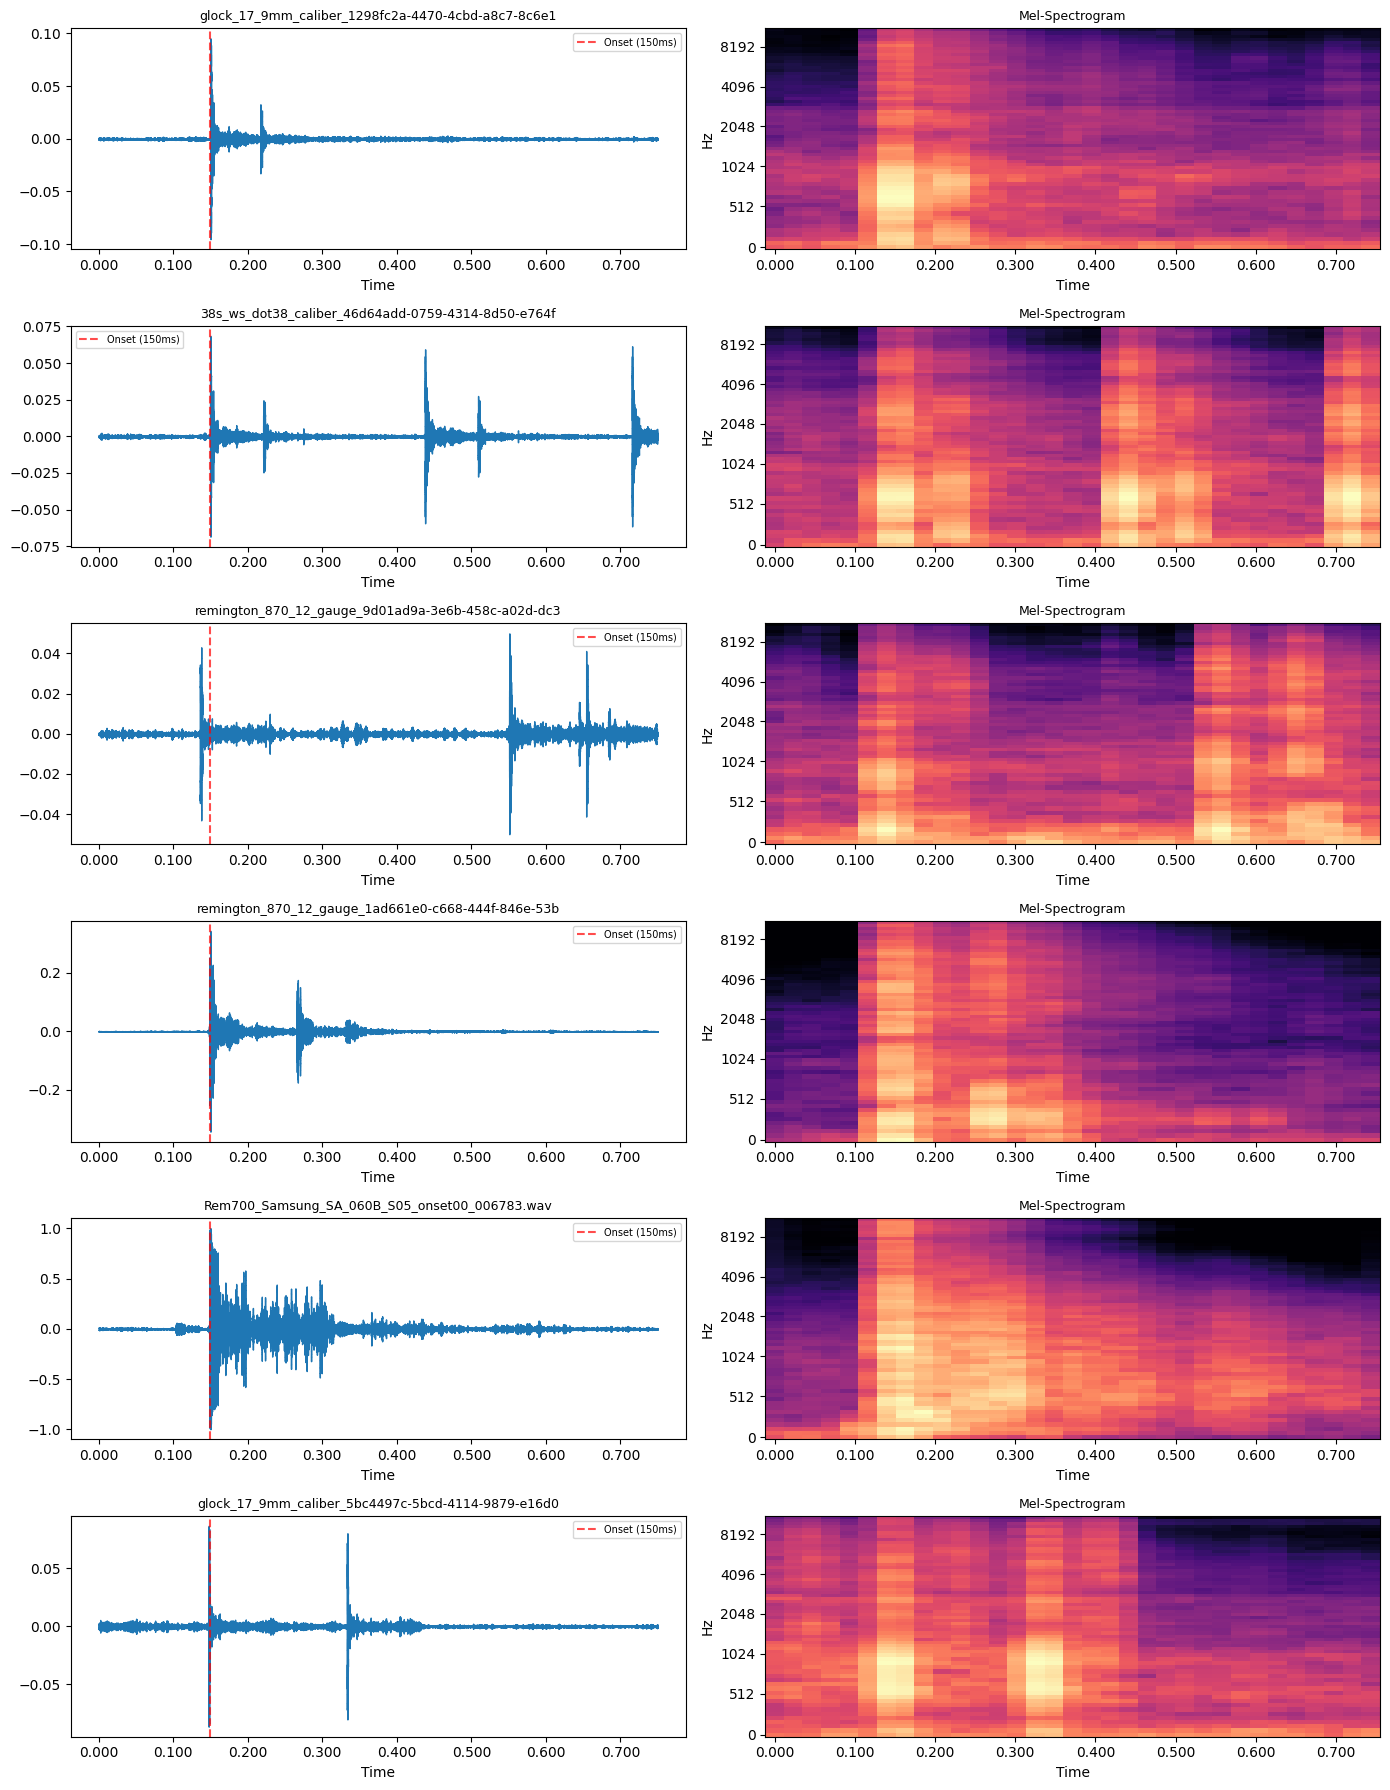


 Listen to verified clips:
  glock_17_9mm_caliber_1298fc2a-4470-4cbd-a8c7-8c6e103d7c4f_chan2_v1_onset00_001316.wav


  38s_ws_dot38_caliber_46d64add-0759-4314-8d50-e764f78208d7_chan0_v0_onset00_000302.wav


  remington_870_12_gauge_9d01ad9a-3e6b-458c-a02d-dc30f4d83f61_chan4_v0_onset03_003269.wav


In [9]:
# ============================================================
# CELL 9: VISUAL AUDIT — Plot random verified clips
# ============================================================
if not verified_files:
    print('No verified files to plot.')
else:
    n_samples = min(6, len(verified_files))
    sample_files = random.sample(verified_files, n_samples)
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 3 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, f in enumerate(sample_files):
        y, sr = librosa.load(f, sr=None)
        
        librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
        axes[i, 0].set_title(f.name[:50], fontsize=9)
        axes[i, 0].axvline(x=PRE_EVENT_MS/1000, color='r', linestyle='--',
                           alpha=0.7, label=f'Onset ({PRE_EVENT_MS}ms)')
        axes[i, 0].legend(fontsize=7)
        
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                ax=axes[i, 1])
        axes[i, 1].set_title('Mel-Spectrogram', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'reports' / 'visual_audit.png', dpi=150)
    plt.show()
    
    print('\n Listen to verified clips:')
    for f in sample_files[:3]:
        print(f'  {f.name}')
        display(ipd.Audio(f))